# Comparison Smoothing

In [ ]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import diffinytrace as dit
import torch
import numpy as np
torch.set_default_dtype(torch.float64)
#torch.set_default_device("cuda:0")
device = "cuda:0"
aperture_radius = 12.7
NBK7 = dit.materials["NBK7"]
#dit.plotting.wavelength.plot(NBK7)

import os
results_folder = "results/comparison_smoothing/"
try:
    os.mkdir("results")
except:
    pass
try:
    os.mkdir(results_folder)
except:
    pass


In [ ]:
n_enviroment = 1.000293
wave_len = 0.5328

lens_pos1D = 0.5
lens_thickness = 6.5
curvature = 0.05
detector_distance = 25.


light_transform = dit.transforms.Offset(torch.tensor([0.0,0.0,0.0]))
light_source = dit.source.CollimatedMonochromatic(light_transform,aperture_radius,wave_len)
light_transform.pos.requires_grad = False

lens_transform = dit.transforms.Distance(lens_pos1D,parent_transform=light_transform)
lens_transform.distance.requires_grad = False
surface1 = dit.Aspheric(curvature=curvature)
surface2 = dit.Plane()
lens1 = dit.Lens(lens_transform,lens_thickness,surface1,surface2,NBK7,aperture_radius)
lens1.lens_thickness.requires_grad = False

detector_transform = dit.transforms.Distance(detector_distance)#25.0+0.5
detector_transform.distance.requires_grad = False
plane_surface = dit.Plane()

det_aperture_radius = aperture_radius*0.5
detector = dit.Detector(detector_transform,plane_surface,det_aperture_radius)


#gridxt = torch.linspace(-aperture_radius,aperture_radius,grid_size)
#grid_delta =gridxt[1]-gridxt[0] 


system = dit.SequentialOpticalSystem({"source":light_source,"lens":lens1,"detector":detector})
system = system.to(device)

In [ ]:
num_pix = 100
__gridxt = torch.linspace(-det_aperture_radius,det_aperture_radius,num_pix)
print("num_pix",num_pix,"grid_delta",__gridxt[1]-__gridxt[0])


num_pix 1000 grid_delta tensor(0.0127)


In [ ]:

x,weights = light_source.sample(30)
x = x.to(device)
sequence = ["source","lens","detector"]
O,D,wave_len,_,RayPaths = system(x,sequence)

#dit.plotting.system3D.plot(system,RayPaths,show_grid=False)
#dit.plotting.system2D.plot(system,RayPaths)

<Figure size 640x480 with 0 Axes>

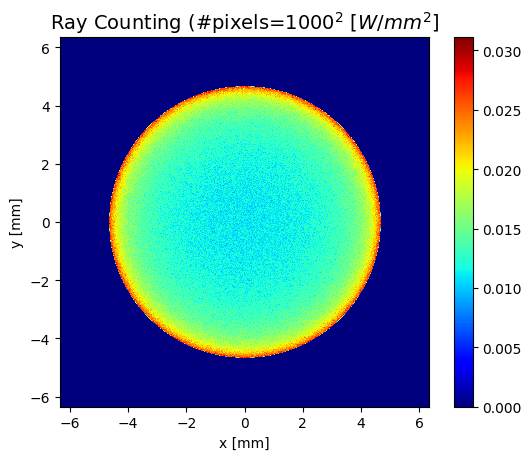

In [ ]:
import numpy as np
import torch
from diffinytrace.render import binned_irradiance

grid_high = dit.target_grid.GridSquare(det_aperture_radius,num_pix*10)
raycounting_list = []
for k in range(100):
    tmp = binned_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,grid=grid_high,num_rays=1000000,method_ray_tracing="monte_carlo",device=device)
    tmp = tmp.detach().cpu()
    raycounting_list.append(tmp)
raycounting_high = torch.mean(torch.stack(raycounting_list),dim=0).detach().cpu()


grid = dit.target_grid.GridSquare(det_aperture_radius,num_pix)
raycounting_list = []
for k in range(100):
    tmp = binned_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,grid=grid,num_rays=1000000,method_ray_tracing="monte_carlo",device=device)
    tmp = tmp.detach().cpu()
    raycounting_list.append(tmp)
raycounting = torch.mean(torch.stack(raycounting_list),dim=0).detach().cpu()


dit.plotting.quantity2D.intensity(raycounting_high,f"Ray Counting (#pixels=${grid_high.x_grid_size}^2$",[-det_aperture_radius,det_aperture_radius])
dit.plotting.quantity2D.intensity(raycounting,f"Ray Counting (#pixels=${grid.x_grid_size}^2$",[-det_aperture_radius,det_aperture_radius])



In [ ]:
smooth_baseline_dict = {}
sigmas = [0.1,0.2,0.5]

def desired_irradiance_func(x):
        device = x.device
        dtype = x.dtype
        
        x = torch.clamp(x, min=-det_aperture_radius, max=det_aperture_radius)
        k = grid.get_k(x,round_to_bounds=True)
        k = k.cpu()
        
        out = raycounting_high.reshape(-1)[k]
        out = out.to(device=device,dtype=dtype)
        return out
    
"""
Here we reuse the implementation of calculating the desired irradiance, to smooth the raycounting result.
"""

for sigma in sigmas:

    smoother = dit.nonimaging.smoothing.GaussianSmootherSquare(det_aperture_radius,num_pix,sigma,device="cpu",num_integration_points_desired=[grid_high.x_grid_size,grid_high.y_grid_size],desired_irradiance_func=desired_irradiance_func)
    smoother.calc_smooth_desired_irradiance()
    smooth_baseline_dict[sigma] = smoother.desired_smooth_irradiance

RuntimeError: [enforce fail at alloc_cpu.cpp:114] data. DefaultCPUAllocator: not enough memory: you tried to allocate 8000000000 bytes.

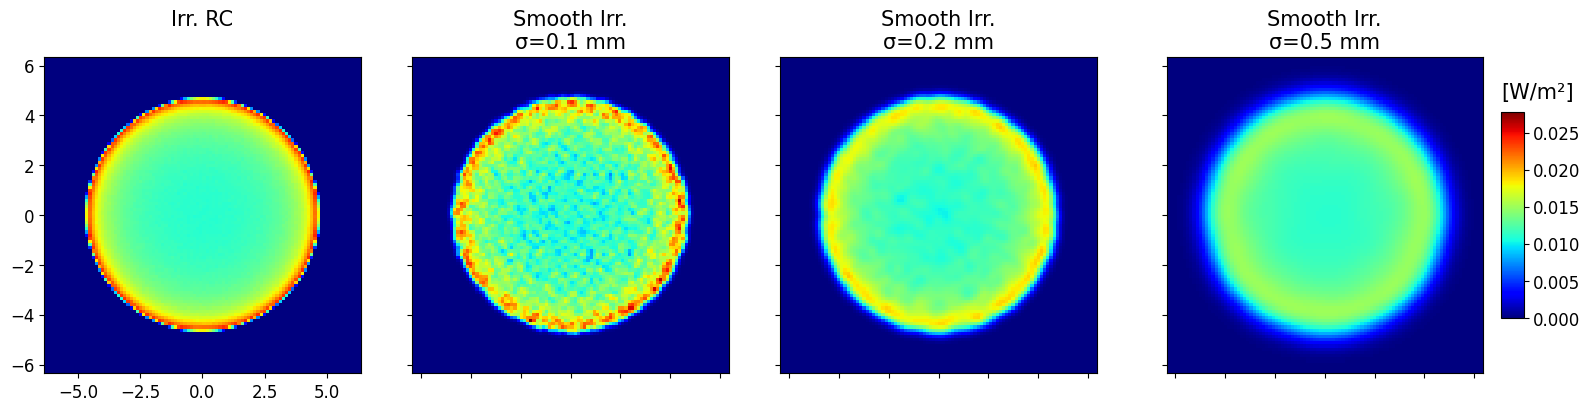

In [ ]:
import matplotlib.pyplot as plt

# Assume you already have:
# - irrs: list of 2D arrays (irradiance maps)
# - rows_extent: list of [xmin, xmax, ymin, ymax] per image
# - sigmas: list of sigma values used for smoothing

cbar_labelsize=12
cbar_title_fontsize=15
# Grid dimensions
rows_extent = [[-det_aperture_radius, det_aperture_radius, -det_aperture_radius, det_aperture_radius]] * (len(sigmas)+1)
irrs = [raycounting] + [val for val in smooth_baseline_dict.values()]
irrs = [irr.cpu() for irr in irrs]
vmin = torch.min(torch.cat(irrs))
vmax = torch.max(torch.cat(irrs))

num_rows = 1
num_cols = len(irrs)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 4), constrained_layout=True)

# Titles for each column
columns_title = ["Irr. RC\n"] + [f"Smooth Irr.\nσ={sigma} mm" for sigma in sigmas]
cmap = "jet"
cbar_title = "[W/m²]"

for k in range(num_cols):
    ax = axes[k]
    img = irrs[k]
    im = ax.imshow(img, extent=rows_extent[k],vmin=vmin,vmax=vmax, origin='lower', cmap=cmap)
    ax.set_title(columns_title[k],fontsize=cbar_title_fontsize)
    #ax.set_xticks([])
    #ax.set_yticks([])
    if k != 0:
        ax.tick_params(labelbottom=False, labelleft=False)
    else:
        ax.tick_params(labelsize=cbar_labelsize)

    # Add colorbar to each subplot
    if k == num_cols-1:
        #cbar = fig.colorbar(im, ax=ax)
        #cbar.set_label(cbar_title)
        
        cbar = plt.colorbar(im,ax=ax,shrink=0.65,aspect=9)  # Add a colorbar for reference
        cbar.ax.tick_params(labelsize=cbar_labelsize)
        cbar.ax.set_title(cbar_title, fontsize=cbar_title_fontsize, pad=10,loc="left")  # Set label above
        offset_text = cbar.ax.yaxis.offsetText
        offset_text.set_size(cbar_labelsize)  # Set the font size
        offset_text.set_ha('left')  # Align the text to the left

#plt.suptitle("Irradiance Maps from Ray Counting and Smoothing", fontsize=16)
    
plt.show()


In [ ]:

    
def run_all_simulations():
    global smoother_baseline_irrs
    
    L2_diff_RC = {}
    L2_diff_smooth = {}

    RMSE_RC = {}
    RMSE_smooth = {}
    #2**np.linspace(8,20,20)
    all_num_rays = np.array(2**np.linspace(5,20,20),dtype=np.int64)
    #,5000,10000

    RMSE_RC_RC = []
    for num_rays in all_num_rays:
            
        irr = binned_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,grid=grid,num_rays=num_rays,method_ray_tracing="monte_carlo",device=device).cpu()
            
        #_L2_diff_RC = torch.sqrt(smoother.get_integral_over_distribution((irr-raycounting)**2.0))
            

        _RMSE_RC = torch.sqrt(torch.mean((irr-raycounting)**2.0))
            
        RMSE_RC_RC.append(_RMSE_RC)
            
        #L2_diff_RC[sigma].append(_L2_diff_RC)
        
    for sigma in sigmas:
        quick_render = lambda num_rays,smoother: dit.render.smoothed_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,smoother=smoother,num_rays=num_rays,method_ray_tracing="monte_carlo",device=device).cpu()
        get_smoother = lambda sigma: dit.nonimaging.smoothing.GaussianSmootherSquare(det_aperture_radius,num_pix,sigma)
        smoother = get_smoother(sigma)
        
        baseline_smooth_irr = smooth_baseline_dict[sigma]

        RMSE_RC[sigma] = []
        RMSE_smooth[sigma] = []
        
        L2_diff_RC[sigma] = []
        L2_diff_smooth[sigma] = []
        

        for num_rays in all_num_rays:
            
            #print("after baseline render")
            
            irr = quick_render(num_rays,smoother)
                
            _L2_diff_RC = torch.sqrt(smoother.get_integral_over_distribution((irr-raycounting)**2.0))
            _L2_diff_smooth = torch.sqrt(smoother.get_integral_over_distribution((irr-baseline_smooth_irr)**2.0))
            

            _RMSE_RC = torch.sqrt(torch.mean((irr-raycounting)**2.0))
            _RMSE_smooth = torch.sqrt(torch.mean((irr-baseline_smooth_irr)**2.0))
            
            RMSE_RC[sigma].append(_RMSE_RC)
            RMSE_smooth[sigma].append(_RMSE_smooth)
            
            L2_diff_RC[sigma].append(_L2_diff_RC)
            L2_diff_smooth[sigma].append(_L2_diff_smooth)
                

    return RMSE_RC, RMSE_smooth, L2_diff_RC, L2_diff_smooth,RMSE_RC_RC,all_num_rays

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np


RMSE_RC, RMSE_smooth, L2_diff_RC, L2_diff_smooth,RMSE_RC_RC,all_num_rays = run_all_simulations()
# Get the number of different ray counts


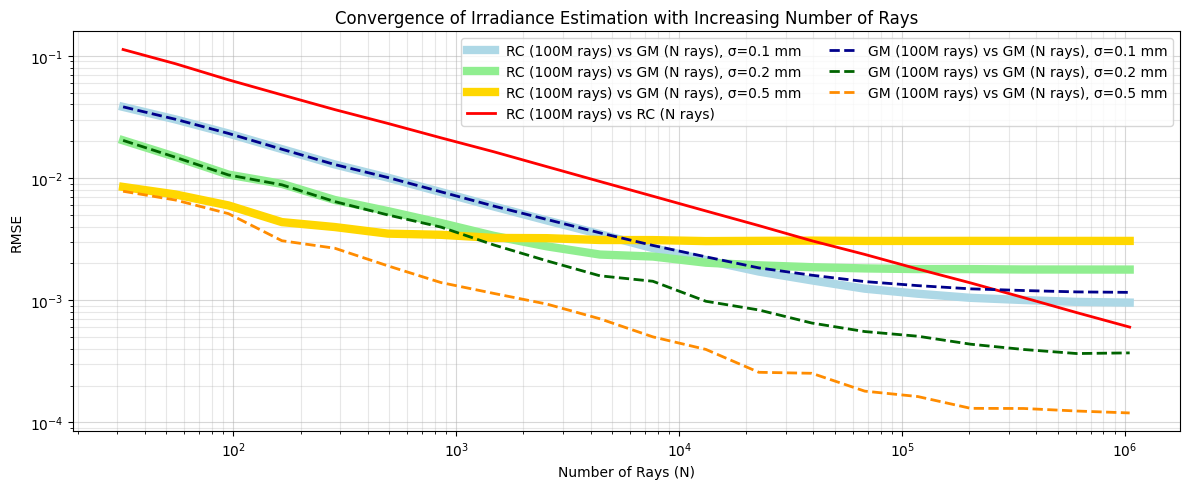

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12,5))

colors = ['lightblue', 'lightgreen', 'gold', 'purple']
for i, sigma in enumerate(RMSE_RC.keys()):
    plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_RC[sigma]],'-',linewidth=6, markersize=4,color=colors[i],label=f"RC (100M rays) vs GM (N rays), σ={sigma} mm",alpha=1)
    
plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_RC_RC],linewidth=2, markersize=4,color ="red",label="RC (100M rays) vs RC (N rays)")
colors = ['darkblue', 'darkgreen', 'darkorange', 'purple']
for i, sigma in enumerate(RMSE_RC.keys()):
    plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_smooth[sigma]],'--',linewidth=2, markersize=4,color = colors[i],label=f"GM (100M rays) vs GM (N rays), σ={sigma} mm", alpha=1)


plt.title('Convergence of Irradiance Estimation with Increasing Number of Rays')#fontsize=16
plt.xlabel('Number of Rays (N)')#, fontsize=14
plt.ylabel('RMSE')#, fontsize=14
plt.legend( ncol=2)
plt.grid(True, 'minor',alpha=0.3)
plt.grid(True,alpha=0.5)
plt.tight_layout()
plt.savefig(results_folder+"irradiance_comparison_RMSE_VA.png", dpi=400, bbox_inches='tight')
        

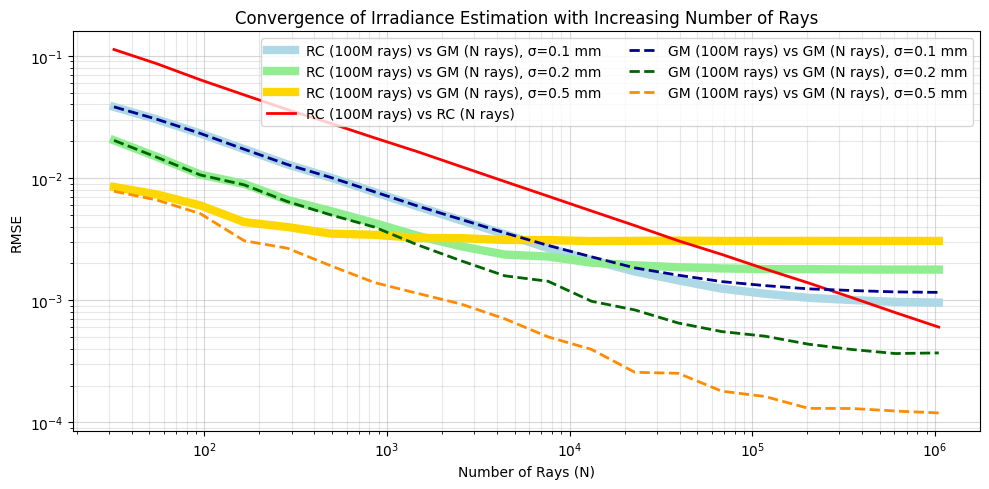

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))

colors = ['lightblue', 'lightgreen', 'gold', 'purple']
for i, sigma in enumerate(RMSE_RC.keys()):
    plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_RC[sigma]],'-',linewidth=6, markersize=4,color=colors[i],label=f"RC (100M rays) vs GM (N rays), σ={sigma} mm",alpha=1)
    
plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_RC_RC],linewidth=2, markersize=4,color ="red",label="RC (100M rays) vs RC (N rays)")
colors = ['darkblue', 'darkgreen', 'darkorange', 'purple']
for i, sigma in enumerate(RMSE_RC.keys()):
    plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_smooth[sigma]],'--',linewidth=2, markersize=4,color = colors[i],label=f"GM (100M rays) vs GM (N rays), σ={sigma} mm", alpha=1)


plt.title('Convergence of Irradiance Estimation with Increasing Number of Rays')#fontsize=16
plt.xlabel('Number of Rays (N)')#, fontsize=14
plt.ylabel('RMSE')#, fontsize=14
plt.legend( ncol=2)
plt.grid(True, 'minor',alpha=0.3)
plt.grid(True,alpha=0.5)
plt.tight_layout()
plt.savefig(results_folder+"irradiance_comparison_RMSE_VB.png", dpi=400, bbox_inches='tight')
